In [1]:
datasets = [
    #"mnist_red30_incremental",
    #"mnist_red30_sml",
    #"fashion_mnist_red50_incremental",
    "fashion_mnist_red50_sml",
    #"fashion_mnist_red50_sml_2",
    #"mnist_red30_sml_2",
]
root = "/Users/federicogiannini/Library/CloudStorage/OneDrive-PolitecnicodiMilano/SML_CL"
nconfs = 6
save = True
suffixes = []
models_to_remove = ["ewc", "mir", "lwf"]

In [2]:
import pickle
import matplotlib.pyplot as plt
import os 
import numpy as np
import pandas as pd

In [3]:
def plot_kappa(perf_values, root, dataset, perf="concept"):
    plt.figure(figsize=(16, 8))

    values_list = []
    for m in perf_values:
        if m=="drifts":
            continue
        values = perf_values[m][perf]["kappa"]
        for d in [0]+perf_values["drifts"][:-1]:
            values_list.append(values[d+1000])
        plt.plot(range(len(values)), values, label=m)            

    for drift in perf_values["drifts"]:
        plt.axvline(x=drift, color='grey', linestyle='--', linewidth=1)

    plt.xlabel("Data points")
    plt.ylabel("Cohen's Kappa")
    plt.title(f"Prequential {perf} on {dataset}")
    plt.legend()
    # plt.grid()
    plt.ylim(min(values_list),1)
    plt.xlim(0, len(values))

    if save:
        plt.savefig(os.path.join(root,f"{dataset}_prequential_{perf}.png"), bbox_inches='tight')
    display(plt.gcf())
    plt.close(plt.gcf())

fashion_mnist_red50_sml concept


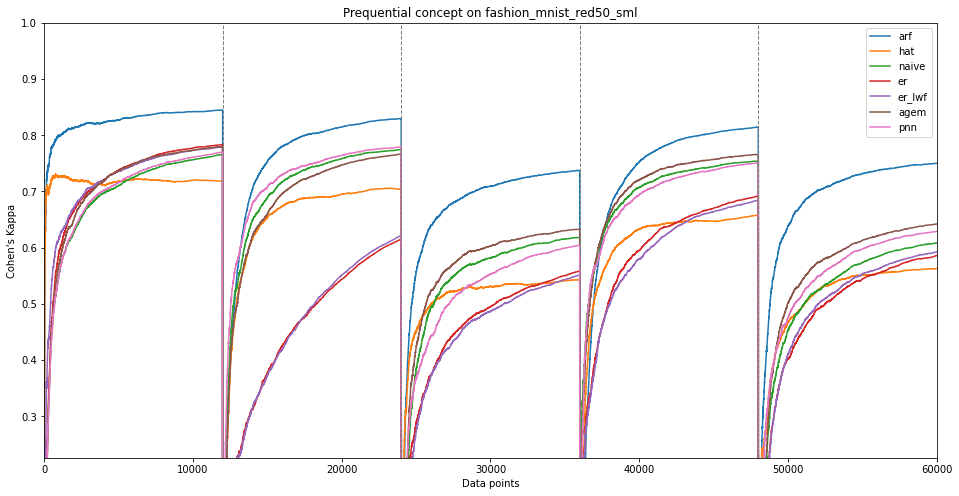

fashion_mnist_red50_sml rolling_500


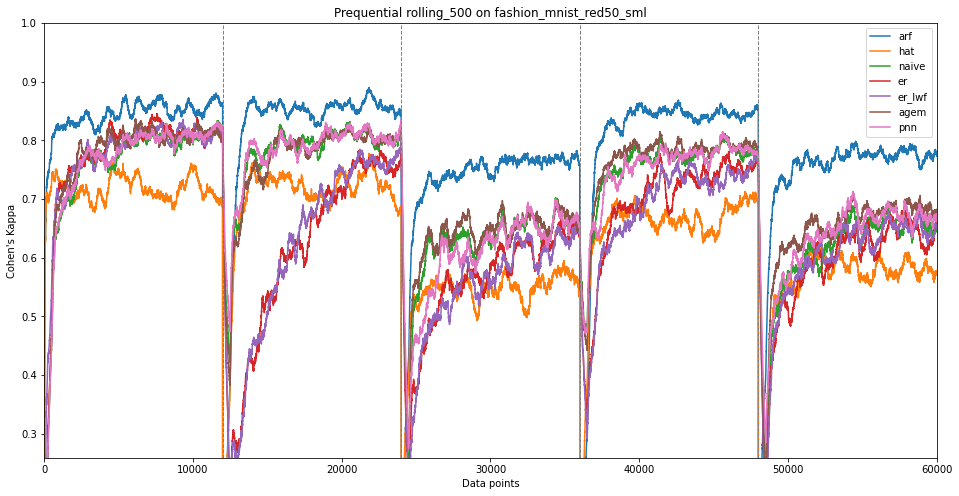

fashion_mnist_red50_sml rolling_reset_500


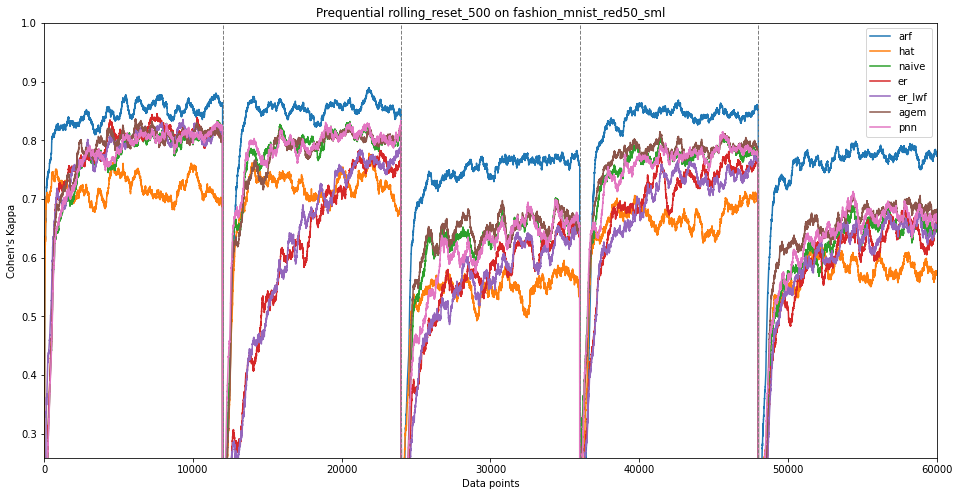

fashion_mnist_red50_sml rolling_1000


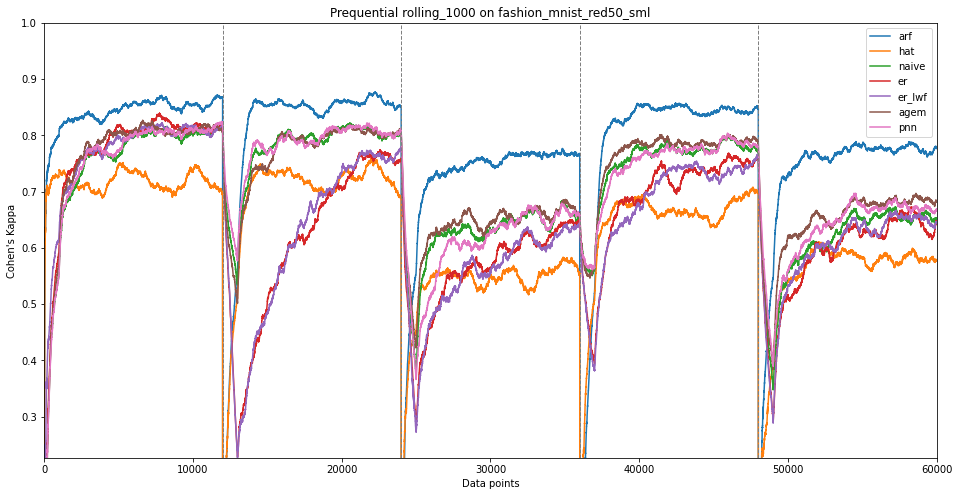

fashion_mnist_red50_sml rolling_reset_1000


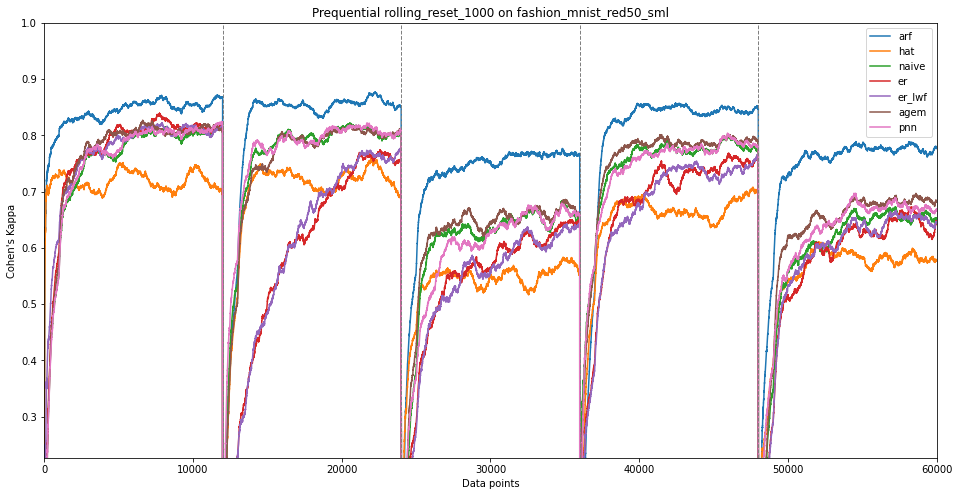

fashion_mnist_red50_sml rolling_5000


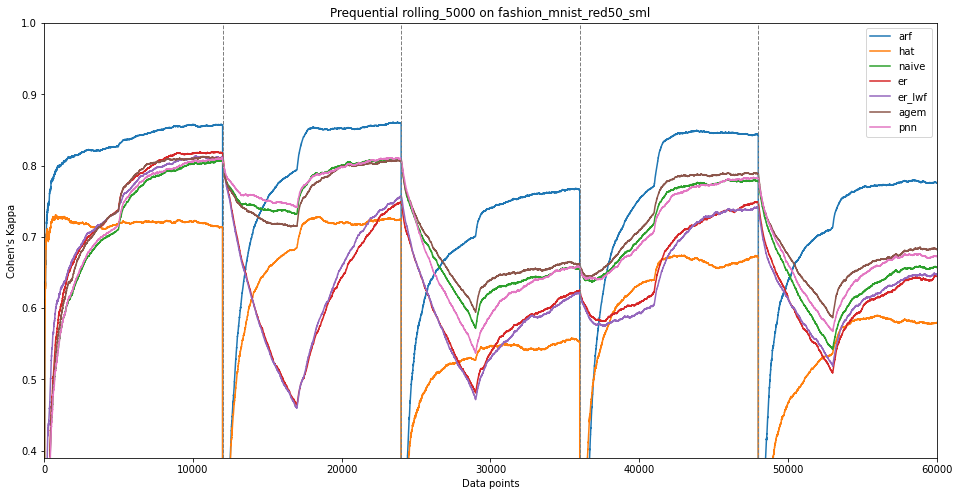

fashion_mnist_red50_sml rolling_reset_5000


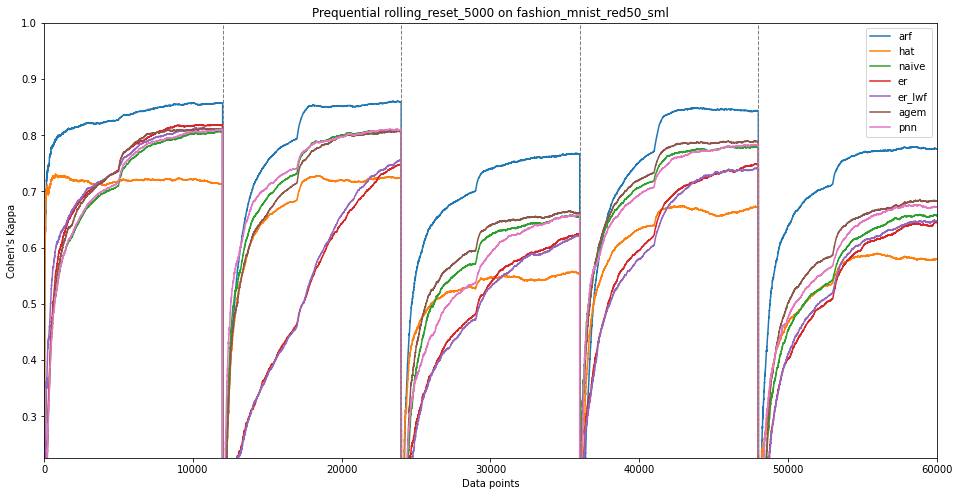

In [4]:
if type(nconfs)==int:
    nconfs = [nconfs] * len(datasets)

for dataset, nconf in zip(datasets, nconfs):
    perf_values = []
    lens = []
    for conf in range(1, nconf+1):
        lens.append(len(pd.read_csv(os.path.join(root, "datasets", f"{dataset}_{conf}conf_train.csv"))))
        with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", f"performance_sml.pkl"), "rb") as f:
            perf_values_ = pickle.load(f)    
    
        with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", "performance_cl.pkl"), "rb") as f:
            p = pickle.load(f)
            del p["drifts"]
            perf_values_.update(p)
    
        for s in suffixes:
            with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", f"performance_cl_{s}.pkl"), "rb") as f:
                p = pickle.load(f)
                del p["drifts"]
                perf_values_.update(p)
            
        perf_values.append(perf_values_)
    
    drifts = [p["drifts"] for p in perf_values]
    for i in range(len(drifts)):
        drifts[i] = [0] + drifts[i] + [lens[i]]
    
    concepts_len = [[d[i+1]-d[i] for i in range(len(d)-1)] for d in drifts]
    concepts_len = np.min(concepts_len, axis=0)
    concepts_len
    
    perf_values_cleaned = pickle.loads(pickle.dumps(perf_values))
    for i in range(len(perf_values)):
        for model in perf_values[i]:
            if model=="drifts" or model in models_to_remove:
                continue
            for m in perf_values[i][model]:
                if m=="drifts":
                    continue
                for metric in ['accuracy', 'kappa']:
                    p = perf_values[i][model][m][metric]
                    perf_values_cleaned[i][model][m][metric] = np.concatenate(
                        [
                            p[drifts[i][j]:drifts[i][j]+concepts_len[j]]
                            for j in range(len(concepts_len))
                        ]
                    )
    
    for i in range(len(perf_values_cleaned)):
        perf_values_cleaned[i]["drifts"] = [concepts_len[0]]
        for j in range(1, len(concepts_len)):
            perf_values_cleaned[i]["drifts"].append(perf_values_cleaned[i]["drifts"][-1] + concepts_len[j])
    
    perf_values_final = {}
    for model in perf_values_cleaned[0]:
        if model=="drifts" or model in models_to_remove:
            continue
        
        perf_values_final[model] = {}
        for m in perf_values_cleaned[0][model]:
            if "freezed" in m:
                continue
            perf_values_final[model][m] = {}
            for metric in ['accuracy', 'kappa']:
                perf_values_final[model][m][metric] = np.mean([p[model][m][metric] for p in perf_values_cleaned], axis=0)
    
    perf_values_final["drifts"] = perf_values_cleaned[0]["drifts"]

    for perf_type in ["concept"] + [f"rolling{reset}_{w}" for w in [500, 1000, 5000] for reset in ["", "_reset"]]:
        print(dataset, perf_type)
        plot_kappa(perf_values_final, root=os.path.join(root, "performance"), dataset=dataset, perf=perf_type)
    print()

In [5]:
with open(os.path.join(root, "performance", f"{dataset}_7conf", f"performance_sml.pkl"), "rb") as f:
    perf_values_sml = pickle.load(f)    
    
with open(os.path.join(root, "performance", f"{dataset}_7conf", "performance_cl.pkl"), "rb") as f:
    perf_values_cl = pickle.load(f)

In [6]:
perf_values_sml['drifts']

[12000, 24000, 36000, 48000]

In [7]:
perf_values_final.keys()

dict_keys(['arf', 'hat', 'naive', 'er', 'er_lwf', 'agem', 'pnn', 'drifts'])

In [8]:
perf_values_final['pnn']['rolling_reset_5000']['kappa']

array([0.        , 0.        , 0.        , ..., 0.6727408 , 0.67261086,
       0.67260936])

In [9]:
perf_values_final['drifts']

[12000, 24000, 36000, 48000, 60000]

In [10]:
perf_values_final['pnn']['rolling_reset_5000']['kappa'][10990+5000]

0.729842853920474

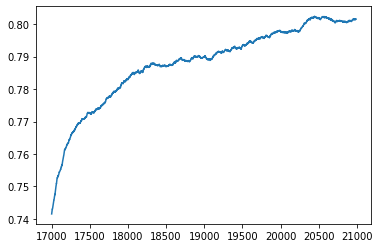

In [11]:
a = 17000
b = 10990+10000

plt.plot(
    np.arange(a, b),
    perf_values_final['pnn']['rolling_reset_5000']['kappa'][a:b]
)

In [12]:
root = "/Users/federicogiannini/Library/CloudStorage/OneDrive-PolitecnicodiMilano/SML_CL/"
path_perf = os.path.join(root, "performance")
dataset = "fashion_mnist_red50_sml_7conf"
path_dataset = os.path.join(root, "datasets_copy")

In [13]:
df = pd.read_csv(os.path.join(path_dataset, f"{dataset}_train.csv"))

In [14]:
df

,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,...,feat42,feat43,feat44,feat45,feat46,feat47,feat48,feat49,target,task
0,-0.152615,7.828728,5.645703,8.031751,3.839663,4.879689,6.387881,4.653626,6.369387,5.324759,...,5.046833,6.023808,3.359693,3.944755,6.397841,4.334767,3.917925,4.841853,1,1
1,0.287730,6.944330,5.462618,6.174664,5.276793,6.124312,4.734198,4.431823,6.630773,4.657762,...,5.086672,6.000254,3.367618,3.943730,6.384065,4.334317,3.888822,4.825342,0,1
2,-0.585444,4.961823,5.466096,7.547742,4.479766,6.740675,3.375781,4.728214,5.715994,4.977297,...,5.124738,6.022253,3.390407,3.950411,6.359904,4.334698,3.876342,4.837650,0,1
3,-0.437810,4.825474,5.413053,7.363330,4.321191,6.744295,3.389259,4.667452,5.953869,4.919701,...,5.136249,6.022023,3.393955,3.951290,6.354752,4.330718,3.879003,4.831366,0,1
4,-0.797749,7.472537,5.833429,7.724430,5.971016,5.895544,4.275633,4.980249,4.708787,5.383501,...,5.087511,6.038474,3.367461,3.961380,6.377184,4.345974,3.890854,4.826367,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3833,0.332246,10.754952,6.280364,3.760676,8.616430,5.014271,5.837624,4.727031,6.000078,5.554587,...,5.016539,5.985057,3.328832,3.962371,6.420470,4.347138,3.937654,4.802386,1,1
3834,2.158866,8.829330,5.995823,1.484906,2.134838,6.254453,5.771453,4.857862,5.751775,5.723013,...,4.997786,5.959835,3.408842,3.941212,6.418070,4.323331,3.966514,4.819981,0,1
3835,9.071732,5.353009,2.171680,5.383161,7.040807,5.639230,5.388143,5.650020,5.404763,5.674776,...,5.027937,5.989535,3.373047,3.970367,6.388264,4.316948,3.887495,4.800276,0,1
3836,-0.601628,-0.919484,5.900745,4.303968,6.947269,5.659420,5.329853,4.872582,5.807671,5.948692,...,5.054176,5.985694,3.368137,3.978227,6.409981,4.366190,3.919871,4.810246,1,1
